In [151]:
import json
import pandas as pd

def load_json_to_df(path):
    with open(path, 'r') as f:
        data = json.load(f)
    
    # Check if it's a FeatureCollection (Dictionary with 'features' key)
    if isinstance(data, dict) and 'features' in data:
        print(f"Detected FeatureCollection in {path}")
        # Extract just the 'properties' from each feature
        flattened_data = [item['properties'] for item in data['features']]
        return pd.DataFrame(flattened_data)
    
    # Check if it's a direct List
    elif isinstance(data, list):
        print(f"Detected direct List in {path}")
        return pd.DataFrame(data)
    
    else:
        raise ValueError(f"Unknown JSON structure in {path}")

# Load both files
df_old = load_json_to_df('/kaggle/input/datasets/mandvis/weather-data-edmonton/weather data/weather_data_till_2012_april.json')
df_new = load_json_to_df('/kaggle/input/datasets/mandvis/weather-data-edmonton/weather data/weather_data_20212_may_2026_feb.json')

# Merge and Clean
df_combined = pd.concat([df_old, df_new], ignore_index=True)

# Convert to datetime to ensure correct sorting
df_combined['LOCAL_DATE'] = pd.to_datetime(df_combined['LOCAL_DATE'])
df_combined = df_combined.sort_values('LOCAL_DATE')

print(f"Merged Dataset Shape: {df_combined.shape}")

Detected direct List in /kaggle/input/datasets/mandvis/weather-data-edmonton/weather data/weather_data_till_2012_april.json
Detected FeatureCollection in /kaggle/input/datasets/mandvis/weather-data-edmonton/weather data/weather_data_20212_may_2026_feb.json
Merged Dataset Shape: (15016, 35)


In [152]:
# List of columns that often contain 'T' or strings
precip_cols = ['TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW', 'SNOW_ON_GROUND']

for col in precip_cols:
    if col in df_combined.columns:
        # Replace 'T' with 0.0 and convert to float
        df_combined[col] = pd.to_numeric(df_combined[col].replace('T', 0.0), errors='coerce')

# Ensure temperature columns are floats as well
temp_cols = ['MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE']
for col in temp_cols:
    df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')

In [153]:
# Drop columns that are >90% null (mostly the _FLAG columns)
thresh = len(df_combined) * 0.1
df_combined = df_combined.dropna(thresh=thresh, axis=1)

# Interpolate missing temperatures (fills gaps based on surrounding days)
df_combined['MEAN_TEMPERATURE'] = df_combined['MEAN_TEMPERATURE'].interpolate(method='linear')
df_combined['MIN_TEMPERATURE'] = df_combined['MIN_TEMPERATURE'].interpolate(method='linear')
df_combined['MAX_TEMPERATURE'] = df_combined['MAX_TEMPERATURE'].interpolate(method='linear')

In [154]:
import numpy as np

# A. Basic Time Parts
df_combined['month'] = df_combined['LOCAL_DATE'].dt.month
df_combined['day_of_year'] = df_combined['LOCAL_DATE'].dt.dayofyear

# B. Cyclical Features (tells the model Dec 31 is close to Jan 1)
df_combined['month_sin'] = np.sin(2 * np.pi * df_combined['month']/12)
df_combined['month_cos'] = np.cos(2 * np.pi * df_combined['month']/12)

# C. Lag Features (Yesterday's weather is a massive predictor for today)
df_combined['temp_lag_1'] = df_combined['MEAN_TEMPERATURE'].shift(1)
df_combined['precip_lag_1'] = df_combined['TOTAL_PRECIPITATION'].shift(1)

# Remove the very first row because it won't have a 'lag' value
df_clean = df_combined.dropna(subset=['temp_lag_1']).reset_index(drop=True)

In [155]:
print(df_clean.info())
df_clean[['LOCAL_DATE', 'MEAN_TEMPERATURE', 'temp_lag_1', 'month_sin']].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15014 entries, 0 to 15013
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   STATION_NAME              15014 non-null  object        
 1   CLIMATE_IDENTIFIER        15014 non-null  object        
 2   ID                        15014 non-null  object        
 3   LOCAL_DATE                15014 non-null  datetime64[ns]
 4   PROVINCE_CODE             15014 non-null  object        
 5   LOCAL_YEAR                15014 non-null  int64         
 6   LOCAL_MONTH               15014 non-null  int64         
 7   LOCAL_DAY                 15014 non-null  int64         
 8   MEAN_TEMPERATURE          15014 non-null  float64       
 9   MIN_TEMPERATURE           15014 non-null  float64       
 10  MAX_TEMPERATURE           15014 non-null  float64       
 11  TOTAL_PRECIPITATION       14987 non-null  float64       
 12  TOTAL_PRECIPITATIO

,LOCAL_DATE,MEAN_TEMPERATURE,temp_lag_1,month_sin
0,1959-05-17,10.15,12.80,0.5
1,1959-05-21,7.50,10.15,0.5
2,1959-05-27,7.00,7.50,0.5
3,1959-05-30,11.10,7.00,0.5
4,1959-05-31,12.30,11.10,0.5


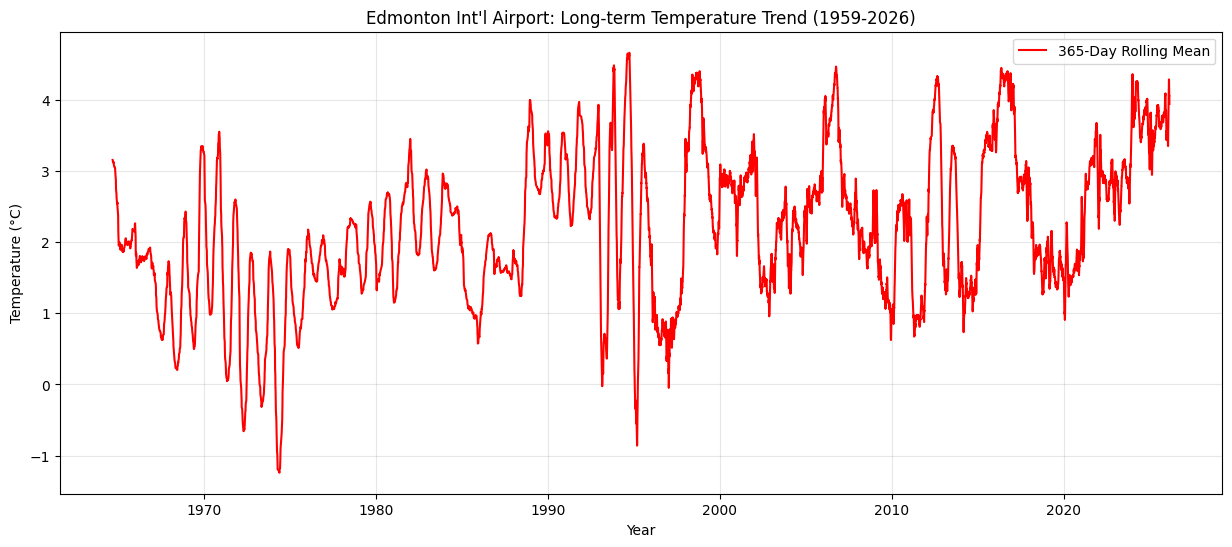

In [156]:
import matplotlib.pyplot as plt

# We use a 365-day rolling average to smooth out the winter/summer swings
# and see the long-term climate trend
plt.figure(figsize=(15, 6))
df_combined['MEAN_TEMP_ROLLING'] = df_combined['MEAN_TEMPERATURE'].rolling(window=365).mean()

plt.plot(df_combined['LOCAL_DATE'], df_combined['MEAN_TEMP_ROLLING'], color='red', label='365-Day Rolling Mean')
plt.title('Edmonton Int\'l Airport: Long-term Temperature Trend (1959-2026)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

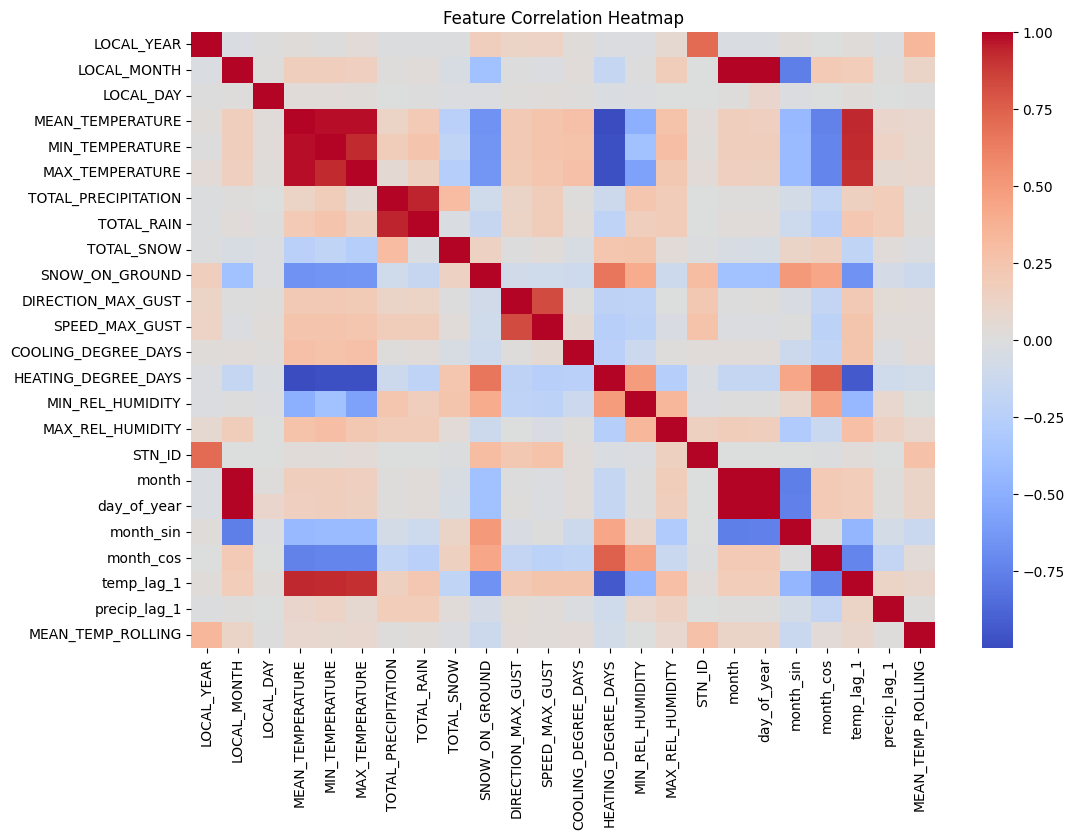

Strongest Predictors for MEAN_TEMPERATURE:
MEAN_TEMPERATURE       1.000000
MAX_TEMPERATURE        0.982929
MIN_TEMPERATURE        0.978699
temp_lag_1             0.933305
COOLING_DEGREE_DAYS    0.275689
Name: MEAN_TEMPERATURE, dtype: float64


In [157]:
import seaborn as sns

# Select only numeric columns for correlation
numeric_df = df_combined.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

# Print top correlations for Mean Temp
print("Strongest Predictors for MEAN_TEMPERATURE:")
print(numeric_df.corr()['MEAN_TEMPERATURE'].sort_values(ascending=False).head(5))

In [158]:
# 1. Set the date as the index
df_combined = df_combined.set_index('LOCAL_DATE')

# 2. Resample to daily frequency ('D'), filling missing days with NaN
df_daily = df_combined.resample('D').asfreq()

# 3. Interpolate Temperatures (Fill the gaps)
# We use linear interpolation for temperature because it changes gradually
temp_cols = ['MEAN_TEMPERATURE', 'MIN_TEMPERATURE', 'MAX_TEMPERATURE']
df_daily[temp_cols] = df_daily[temp_cols].interpolate(method='linear')

# 4. Fill Precipitation with 0 (If a day is missing, we assume no rain/snow recorded)
precip_cols = ['TOTAL_PRECIPITATION', 'TOTAL_RAIN', 'TOTAL_SNOW']
df_daily[precip_cols] = df_daily[precip_cols].fillna(0)

# 5. Re-generate the lag features on the now-continuous data
df_daily['temp_lag_1'] = df_daily['MEAN_TEMPERATURE'].shift(1)
df_daily = df_daily.dropna(subset=['temp_lag_1']) # Drop the very first day

print(f"Dataset expanded from 15,014 to {len(df_daily)} continuous days.")

Dataset expanded from 15,014 to 24403 continuous days.


In [159]:
# 1. Rolling Mean (Short-term trend over 3 and 7 days)
df_daily['temp_roll_3'] = df_daily['MEAN_TEMPERATURE'].shift(1).rolling(window=3).mean()
df_daily['temp_roll_7'] = df_daily['MEAN_TEMPERATURE'].shift(1).rolling(window=7).mean()

# 2. Temperature Delta (Is it getting colder or warmer?)
# This is the "Velocity" of the weather
df_daily['temp_change_1d'] = df_daily['temp_lag_1'] - df_daily['MEAN_TEMPERATURE'].shift(2)

# 3. Standard Deviation (Is the weather currently "Unstable"?)
df_daily['temp_std_7'] = df_daily['MEAN_TEMPERATURE'].shift(1).rolling(window=7).std()

# Drop the new NaNs created by rolling windows
df_daily = df_daily.dropna(subset=['temp_roll_7', 'temp_change_1d'])

In [160]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


# features = ['temp_lag_1', 'month_sin', 'month_cos', 'temp_roll_3', 'temp_roll_7', 'temp_change_1d', 'temp_std_7']


# features = ['temp_lag_1', 'month_sin', 'month_cos', 'temp_change_1d']
features = ['temp_lag_1', 'month_sin', 'month_cos', 'precip_lag_1', 'temp_change_1d']

X = df_daily[features]
y = df_daily['MEAN_TEMPERATURE']

# Time-series split (keeping the same index logic)
split_idx = int(len(df_daily) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Train a more aggressive model (Higher depth allows it to reach those peaks)
# model = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
# model = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42)
model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"New MAE: {mean_absolute_error(y_test, y_pred):.2f}°C")




# # 1. Select "Legal" Features (Things we know in advance)
# features = ['temp_lag_1', 'month_sin', 'month_cos', 'precip_lag_1']
# X = df_daily[features]
# y = df_daily['MEAN_TEMPERATURE']

# # 2. Time-Series Split (80% Train, 20% Test)
# # Important: We don't shuffle weather data because the order matters!
# split_idx = int(len(df_daily) * 0.8)
# X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
# y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# # 3. Train the Model
# model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
# model.fit(X_train, y_train)

# # 4. Make Predictions
# y_pred = model.predict(X_test)

# 5. Evaluate vs. Persistence Baseline
# Baseline: Guessing today is exactly the same as yesterday
baseline_preds = X_test['temp_lag_1'] 

model_mae = mean_absolute_error(y_test, y_pred)
base_mae = mean_absolute_error(y_test, baseline_preds)

print(f"AI Model Error (MAE): {model_mae:.2f}°C")
print(f"Simple Guess Error (MAE): {base_mae:.2f}°C")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

New MAE: 2.73°C
AI Model Error (MAE): 2.73°C
Simple Guess Error (MAE): 2.86°C
R2 Score: 0.9124


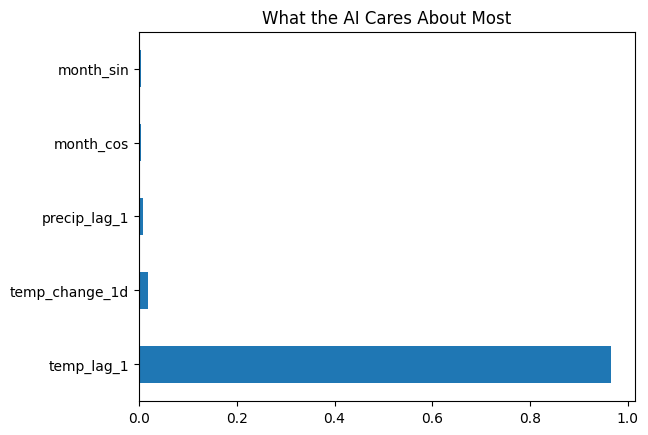

In [161]:
import pandas as pd
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind='barh', title='What the AI Cares About Most')
plt.show()

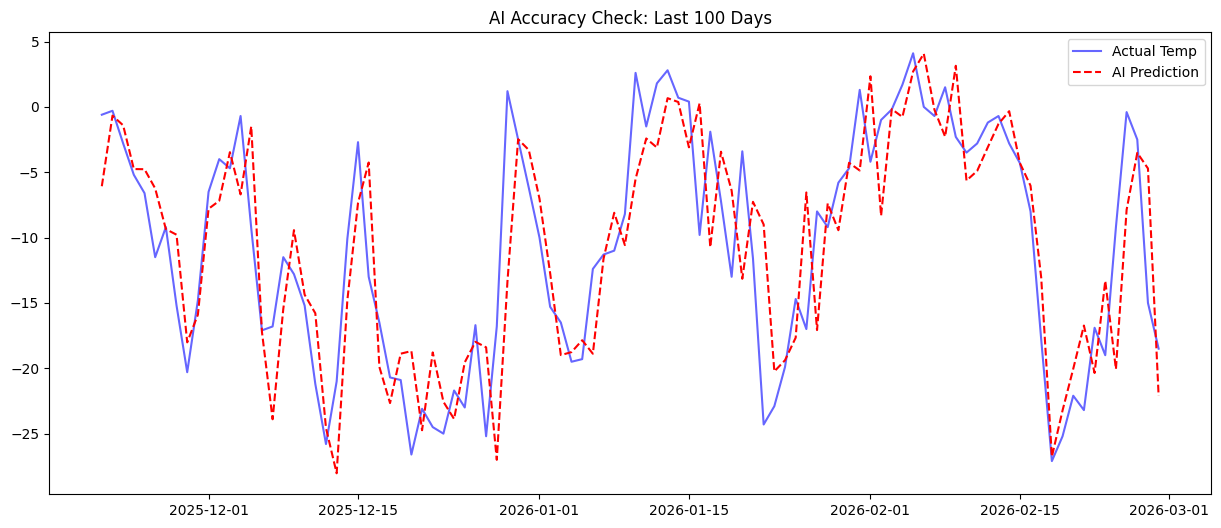

In [162]:
import matplotlib.pyplot as plt

# Plotting the last 100 days to see the "Gap" between AI and Reality
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[-100:], y_test.values[-100:], label='Actual Temp', color='blue', alpha=0.6)
plt.plot(y_test.index[-100:], y_pred[-100:], label='AI Prediction', color='red', linestyle='--')

plt.title("AI Accuracy Check: Last 100 Days")
plt.legend()
plt.show()

In [163]:
import joblib

# 1. Save the trained model to a file
joblib.dump(model, 'edmonton_weather_model_v1.pkl')

# 2. Save your 'X_test' and 'y_test' for later visualization
X_test.to_csv('weather_test_features.csv')
y_test.to_csv('weather_test_actuals.csv')

print("Model and Test Data saved successfully!")

Model and Test Data saved successfully!


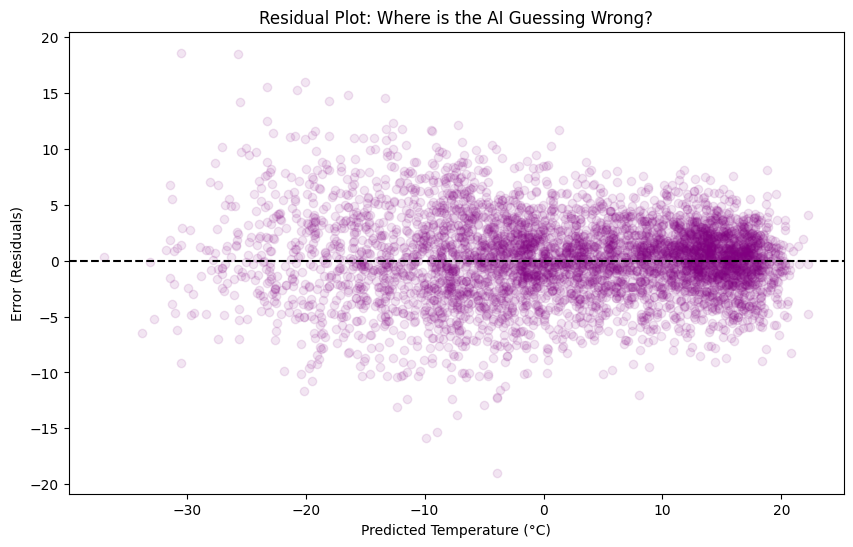

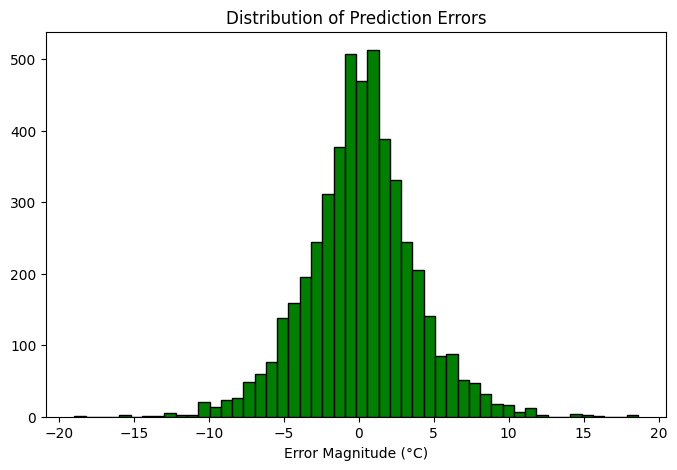

In [164]:
import matplotlib.pyplot as plt

# Calculate Residuals (Actual minus Predicted)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.1, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residual Plot: Where is the AI Guessing Wrong?')
plt.xlabel('Predicted Temperature (°C)')
plt.ylabel('Error (Residuals)')
plt.show()
# Check if the errors follow a "Normal Distribution" (The Bell Curve)
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, color='green', edgecolor='black')
plt.title('Distribution of Prediction Errors')
plt.xlabel('Error Magnitude (°C)')
plt.show()

In [165]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mandvis/weather-data-edmonton/weather data/weather_data_till_2012_april.json
/kaggle/input/datasets/mandvis/weather-data-edmonton/weather data/weather_data_20212_may_2026_feb.json
